# 06 · Economic & Policy Analysis

Descriptive public-finance modelling: the **guns-vs-butter** tradeoff, the **interest-burden** squeeze on social spending, and how priorities shifted across geopolitical **eras**.

In [1]:
import sys
from pathlib import Path
# Locate the project root (the folder containing src/globalbudget) and add src to path.
_p = Path.cwd()
while _p != _p.parent and not (_p / "src" / "globalbudget").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from globalbudget import data_loader, cleaning, features, viz, forecasting
viz.set_theme()
pd.set_option("display.max_columns", 40)
print("Project root:", _p)


Project root: /Users/shrutichougule/Documents/global budget


In [2]:
wide = data_loader.load_master()
feat = features.build_ml_frame(wide)  # adds Social_Spend_Pct, Guns_Butter_Ratio, Era

## 1. Guns vs butter over time (global average)
Cross-country mean defense share vs combined social share by year.

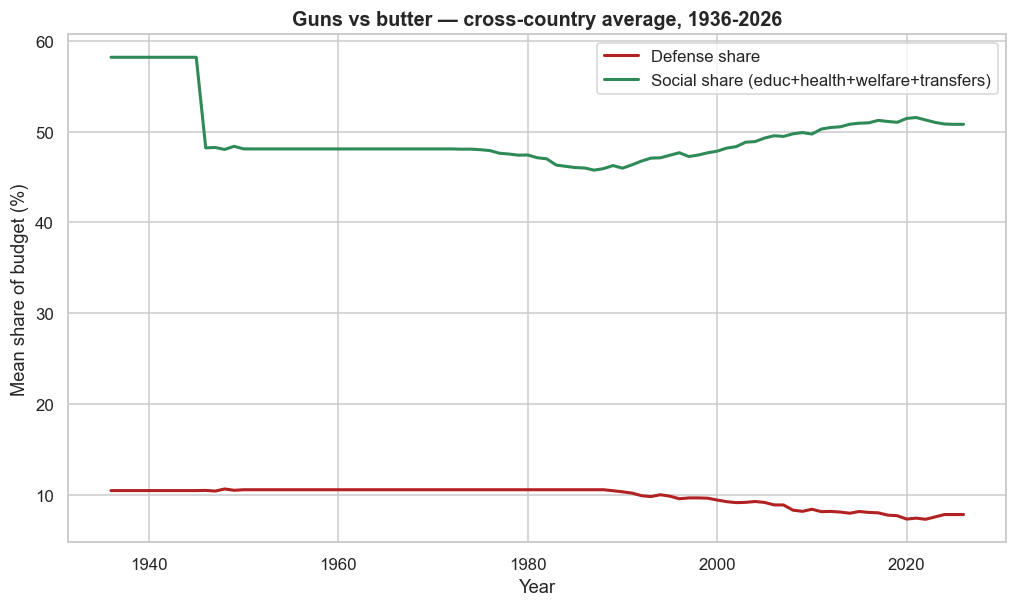

In [3]:
g = feat.groupby('Year').agg(Defense=('Defense_Percentage','mean'),
                              Social=('Social_Spend_Pct','mean')).reset_index()
fig, ax = plt.subplots(figsize=(11,6))
ax.plot(g.Year, g.Defense, label='Defense share', color='firebrick', lw=2)
ax.plot(g.Year, g.Social, label='Social share (educ+health+welfare+transfers)', color='seagreen', lw=2)
ax.set_xlabel('Year'); ax.set_ylabel('Mean share of budget (%)')
ax.set_title('Guns vs butter — cross-country average, 1936-2026'); ax.legend()
viz.save(fig, 'policy_guns_vs_butter'); plt.show()

## 2. Does a higher interest burden crowd out social spending?
Country-year scatter of interest share vs social share, with a fitted trend.

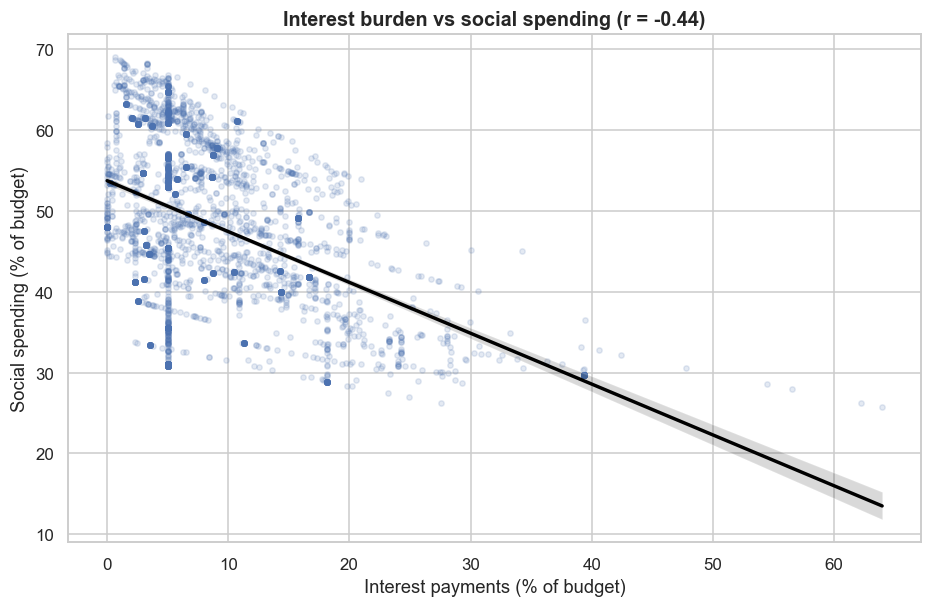

In [4]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(data=feat, x='Interest_Payments_Percentage', y='Social_Spend_Pct',
            scatter_kws={'alpha':0.15,'s':12}, line_kws={'color':'black'}, ax=ax)
corr = feat[['Interest_Payments_Percentage','Social_Spend_Pct']].corr().iloc[0,1]
ax.set_title(f'Interest burden vs social spending (r = {corr:.2f})')
ax.set_xlabel('Interest payments (% of budget)'); ax.set_ylabel('Social spending (% of budget)')
viz.save(fig, 'policy_interest_vs_social'); plt.show()

## 3. Priorities by era
Mean category share within each geopolitical era.

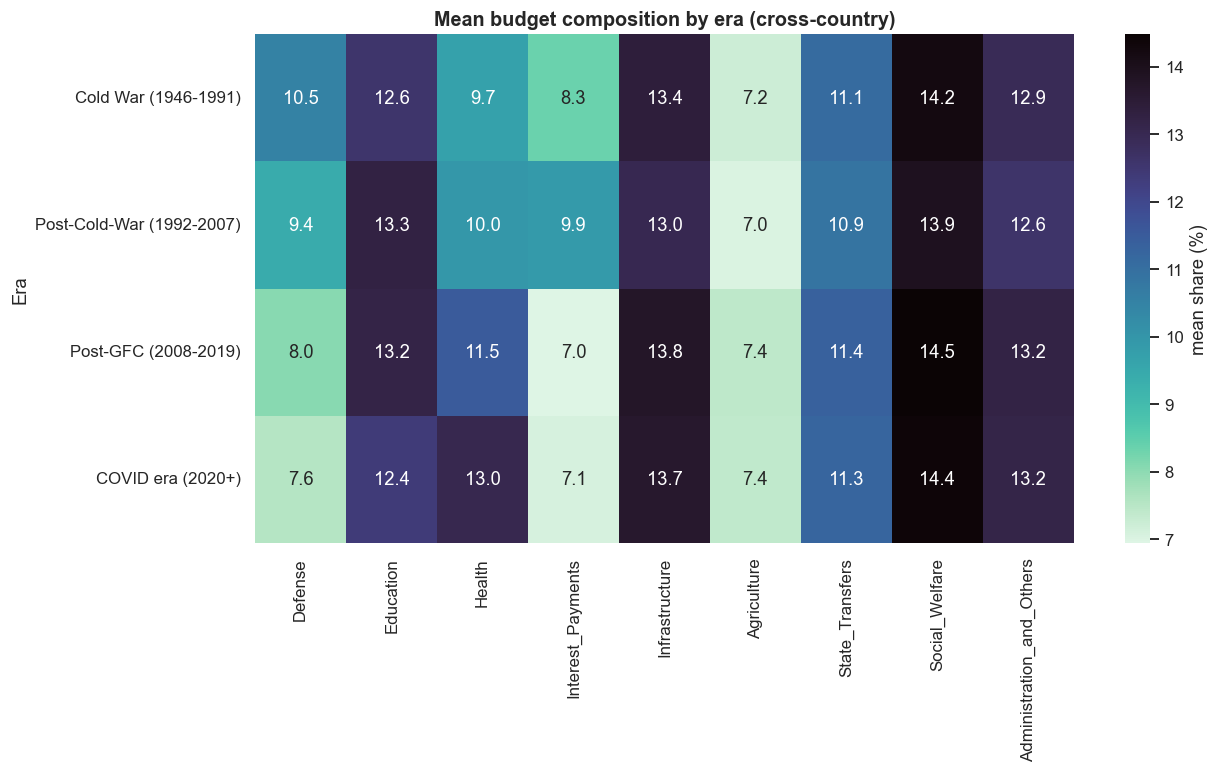

In [5]:
era_order = ['Cold War (1946-1991)','Post-Cold-War (1992-2007)','Post-GFC (2008-2019)','COVID era (2020+)']
pct_cols = data_loader.PCT_COLS
by_era = feat.groupby('Era')[pct_cols].mean()
by_era = by_era.reindex([e for e in era_order if e in by_era.index])
by_era.columns = [c.replace('_Percentage','') for c in by_era.columns]
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(by_era, annot=True, fmt='.1f', cmap='mako_r', ax=ax, cbar_kws={'label':'mean share (%)'})
ax.set_title('Mean budget composition by era (cross-country)')
viz.save(fig, 'policy_era_heatmap'); plt.show()

## 4. Correlations between spending functions
Which priorities move together (or trade off) across the whole panel.

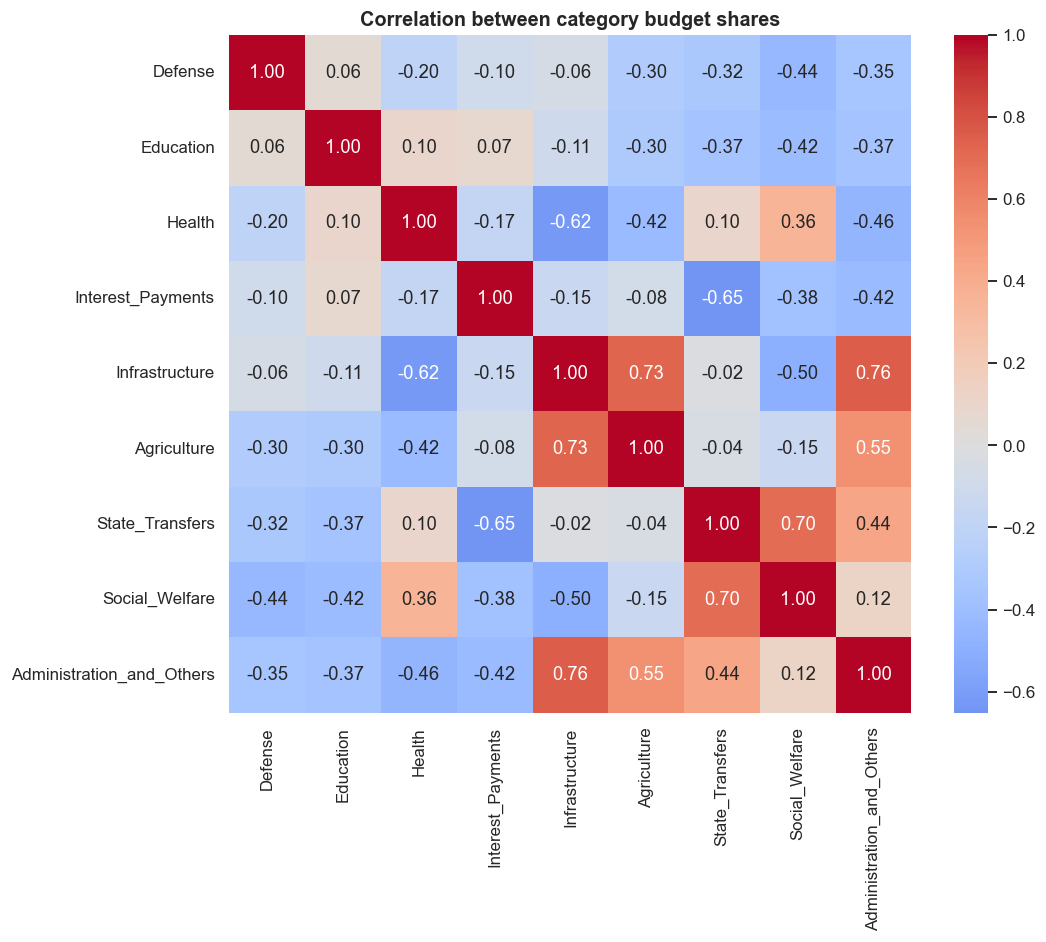

In [6]:
cols = data_loader.PCT_COLS
cm = feat[cols].corr()
cm.index = [c.replace('_Percentage','') for c in cm.index]
cm.columns = [c.replace('_Percentage','') for c in cm.columns]
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation between category budget shares')
viz.save(fig, 'policy_correlation_heatmap'); plt.show()

## 5. Biggest movers: defense share, Cold War vs today
Change in defense share from the Cold War average to the most recent 5 years.

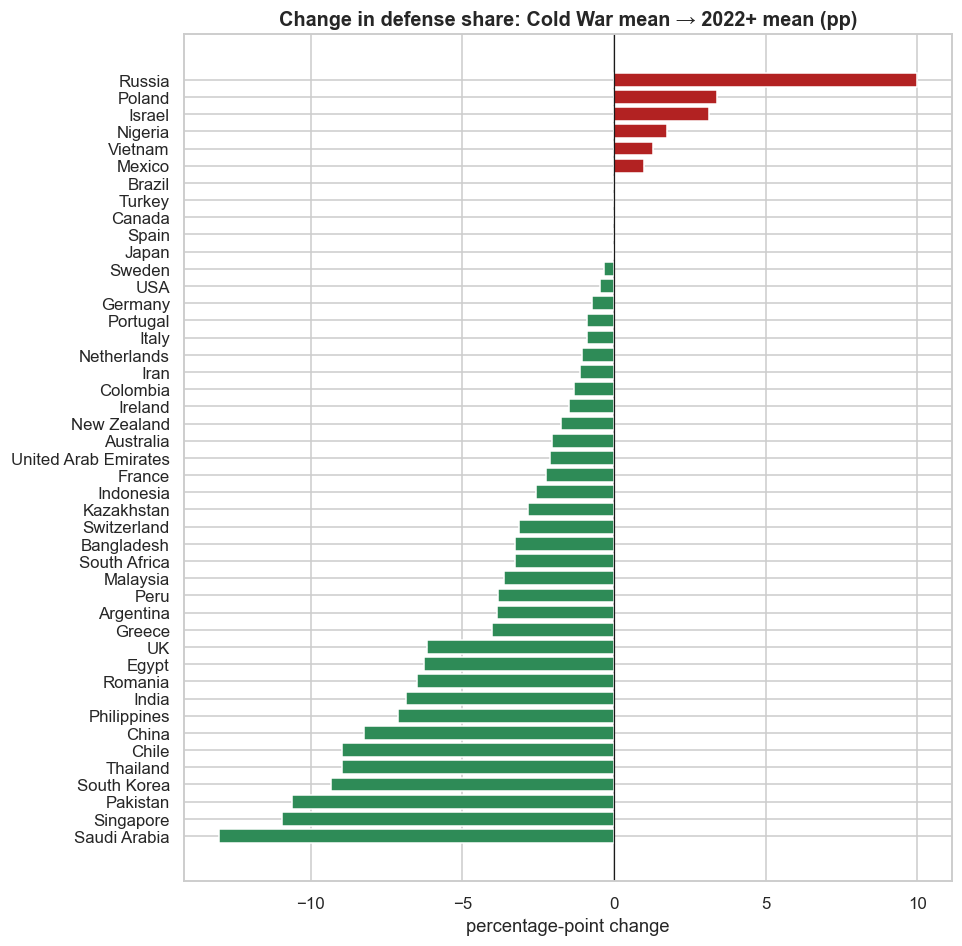

In [7]:
cw = feat[feat.Era=='Cold War (1946-1991)'].groupby('Country').Defense_Percentage.mean()
recent = feat[feat.Year>=2022].groupby('Country').Defense_Percentage.mean()
chg = (recent - cw).dropna().sort_values()
fig, ax = plt.subplots(figsize=(9,10))
colors = ['seagreen' if v<0 else 'firebrick' for v in chg.values]
ax.barh(chg.index, chg.values, color=colors)
ax.set_title('Change in defense share: Cold War mean → 2022+ mean (pp)')
ax.set_xlabel('percentage-point change'); ax.axvline(0, color='k', lw=0.8)
viz.save(fig, 'policy_defense_change'); plt.show()

## Policy takeaways
* The cross-country defense share fell after the Cold War; social spending trended up — a broad 'butter over guns' shift, partially reversed in recent years for some states.
* Interest burden and social spending are negatively associated: debt service crowds out social outlays.
* Era heatmaps show welfare/health rising over time while agriculture and admin compress.

See `reports/findings.md` for the consolidated write-up.